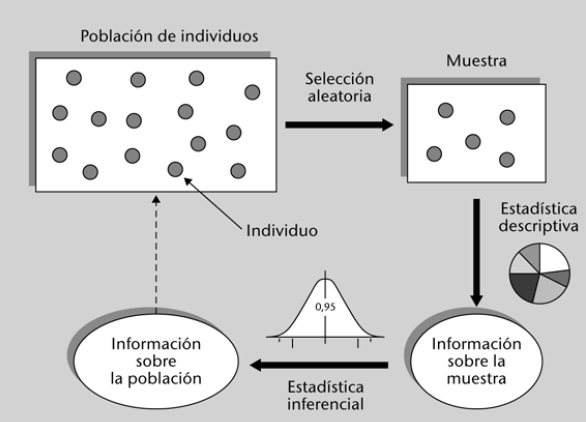

#Probabilidad y estadística 2025

# Trabajo Especial


Alumnos: Honorato Bonetto Diego Valentin, Luca Julián Sosa Bret

Carrera Alumno 1: Lic. En ciencias de la computación

Carrera Alumno 2: Lic. En ciencias de la computación

# Ejercicios

1. Cargue el archivo `generated_dataset_2025.csv` en un dataframe llamado   `new_df`.
2. Calcule las siguientes medidas de posición y dispersión para la columna age: mediana, media, desviación estandard, resta entre el primer y tercer cuartil (rango intercuartílico).
3. Utilice la función `value_counts`  de pandas para calcular la probabilidad en lugar de la frecuencia de todas las respuestas posibles de la columna `zodiac_sign`.
4. Describa el tipo de cada variable aleatoria y responda

- `gender`: ??
- `age`: ??
- `zodiac_sign`: ??3
- `profession`: ??
- `junior_programmer_salary`: ??
- `senior_programmer_salary`: ??:

  a. La variable `age`, ¿es discreta o continua?

  b. ¿Qué valores pueden tomar `junior_programmer_salary` y `senior_programmer_salary`?

  c. Los signos del zodiaco siguen un orden (al igual que los días y los meses del año). ¿Podríamos decir que `zodiac_sign` tiene tipo ordinal?

5.
  a. Calcular la probabilidad de que una respuesta tenga `gender=Hombre` dado que sabemos que tiene `zodiac_sign=Tauro`.

  b. Calcular si los conjuntos de respuestas con `gender=Hombre` y `zodiac_sign=Tauro` son independientes o no, utilizando dos métodos.

6. Grafique la distribución acumulada de la edad,  agrupada por `gender`.

7.  Grafique dos histogramas superpuestos, comparando las distribuciones de los salarios para seniors y para juniors. Utilice `clean_outliers` y grafique nuevamente. ¿Cuál es el valor por defecto? ¿Qué sucede cuando es muy bajo? ¿Y cuando es muy alto? ¿A qué distribuciones de las vistas en clase se parece más cada histograma? ¿Son distintas? ¿Qué las diferencia?

7. Usando los boxplots describa la distribución del ingreso senior en el rango de edad construido y agrupado por `gender`. ¿Son simétricas, sesgada a la izquierda o a la derecha?

8. Realice una comparación entre la edad y ambas estimaciones de sueldo **sin outliers**  usando pairplots.

9. ¿Qué puede decir de las distribuciones de salarios junior y senior?


# ej 1)
Cargue el archivo `generated_dataset_2025.csv` en un dataframe llamado   `new_df`.

In [ ]:
# ej 1
import pandas
import seaborn
import numpy
import matplotlib.pyplot as plt
from numpy.random.mtrand import f
from google.colab import files

new_df = pandas.read_csv("generated_dataset_2025.csv") # subir en la carpeta principal de files, cuando se recarga el notebook se pierden
new_df = new_df.drop(columns=["Unnamed: 0"])
pandas.options.display.float_format = '{:.3f}'.format
# print(new_df)

# ej 2)
Calcule las siguientes medidas de posición y dispersión para la columna age: mediana, media, desviación estandard, resta entre el primer y tercer cuartil (rango intercuartílico).

In [ ]:
#ej 2
age_column = new_df.age.describe()
print("ej 2) \n")
print("media:\n",age_column["mean"])
print("desviacion estandar:\n",age_column["std"] )
print("mediana:\n", age_column["50%"])
print("resta entre el primer y tercer cuartil (rango intercuartilico):\n",age_column["75%"] - age_column["25%"])
print("\n")


ej 2) 

media:
 39.4976
desviacion estandar:
 4.959219053980521
mediana:
 39.0
resta entre el primer y tercer cuartil (rango intercuartilico):
 7.0




# ej 3)
Utilice la función `value_counts`  de pandas para calcular la probabilidad en lugar de la frecuencia de todas las respuestas posibles de la columna `zodiac_sign`.

In [ ]:
#ej 3
print("ej 3) \n")
zodiac_sign_counts = new_df.zodiac_sign.value_counts(normalize=True)
print(zodiac_sign_counts)
print("\n")

ej 3) 

zodiac_sign
Leo           0.089
Virgo         0.087
Géminis       0.087
Libra         0.086
Cáncer        0.085
Capricornio   0.084
Sagitario     0.082
Escorpio      0.081
Picis         0.081
Acuario       0.080
Tauro         0.080
Aries         0.079
Name: proportion, dtype: float64




# ej 4)
Describa el tipo de cada variable aleatoria y responda

- `gender`: cualitativa nominal (clasificar)
- `age`: cuantitativa continua (medir)
- `zodiac_sign`: cualitativa nominal (clasificar)
- `profession`: cualitativa nominal (clasificar)
- `junior_programmer_salary`: cuantitativa continua (medir)
- `senior_programmer_salary`: cuantitativa continua (medir)

  a. La variable `age`, ¿es discreta o continua?

age es una variable cuantitativa continua, ya que habla de tiempo transcurrido de vida, pero en el dataset proporcionado, son años enteros.

  b. ¿Qué valores pueden tomar `junior_programmer_salary` y `senior_programmer_salary`?

Respondido en codigo

  c. Los signos del zodiaco siguen un orden (al igual que los días y los meses del año). ¿Podríamos decir que `zodiac_sign` tiene tipo ordinal?

no existe una jerarquia impuesta entre los signos del zodiaco, asi que no es ordinal, es nominal



In [ ]:
print("ej4, b)")
junior_min = new_df["junior_programmer_salary"].min()
junior_max = new_df["junior_programmer_salary"].max()
senior_min = new_df["senior_programmer_salary"].min()
senior_max = new_df["senior_programmer_salary"].max()
print(f"junior_programmer_salary toma valores entre {junior_min} y {junior_max}")
print(f"senior_programmer_salary toma valores entre {senior_min} y {senior_max}")

ej4, b)
junior_programmer_salary toma valores entre 9000.0 y 147000.0
senior_programmer_salary toma valores entre 23000.0 y 334000.0


#ej 5 a, b (Metodo I, II))

  a. Calcular la probabilidad de que una respuesta tenga `gender=Hombre` dado que sabemos que tiene `zodiac_sign=Tauro`.

  b. Calcular si los conjuntos de respuestas con `gender=Hombre` y `zodiac_sign=Tauro` son independientes o no, utilizando dos métodos.

In [ ]:
#ej 5
print("ej 5, a)")
# ! P(A|B) = P(hombre|Tauro)
p_hombre_dado_tauro = len(new_df[(new_df.gender == 'Hombre') &
                                 (new_df.zodiac_sign == 'Tauro')]) / len(new_df[new_df.zodiac_sign == 'Tauro'])
print("P(Hombre|Tauro):", p_hombre_dado_tauro)

print("\nej 5, b)")
print("Metodo I (P(AnB) vs P(A)P(B))")
# ! P(AnB) vs P(A)P(B)

# ! P(A), probabilidad de que la persona seleccionada sea Hombre
p_hombre = len(new_df[new_df.gender == 'Hombre']) / len(new_df)

# ! P(B), probabilidad de que la persona sea seleccionada sea tauro:
p_tauro = len(new_df[new_df.zodiac_sign == 'Tauro']) / len(new_df)

#  ! P(AnB)
p_hombre_y_tauro = len(new_df[(new_df.gender == 'Hombre') & (new_df.zodiac_sign == 'Tauro')]) / len(new_df)

# ! P(A)P(B)
pa_pb = p_hombre * p_tauro

if abs(p_hombre_y_tauro - pa_pb) < 0.00001:
    print("Los conjuntos son independientes (criterio P(AnB) = P(A)P(B))\n")
else:
    print("Los conjuntos NO son independientes (criterio P(AnB) != P(A)P(B))\n")

print("Metodo II (P(A|B) = P(A))")
# ! P(A|B) = P(A)

if abs(p_hombre_dado_tauro - p_hombre) < 0.000001:
    print("A y B independientes (criterio P(A|B) = P(A))\n")
else:
    print("A y B NO independientes (criterio P(A|B) != P(A))\n")



ej 5, a)
P(Hombre|Tauro): 0.5895522388059702

ej 5, b)
Metodo I (P(AnB) vs P(A)P(B))
Los conjuntos NO son independientes (criterio P(AnB) != P(A)P(B))

Metodo II (P(A|B) = P(A))
A y B NO independientes (criterio P(A|B) != P(A))



# ej 6)

Grafique la distribución acumulada de la edad,  agrupada por `gender`.


ej 6)


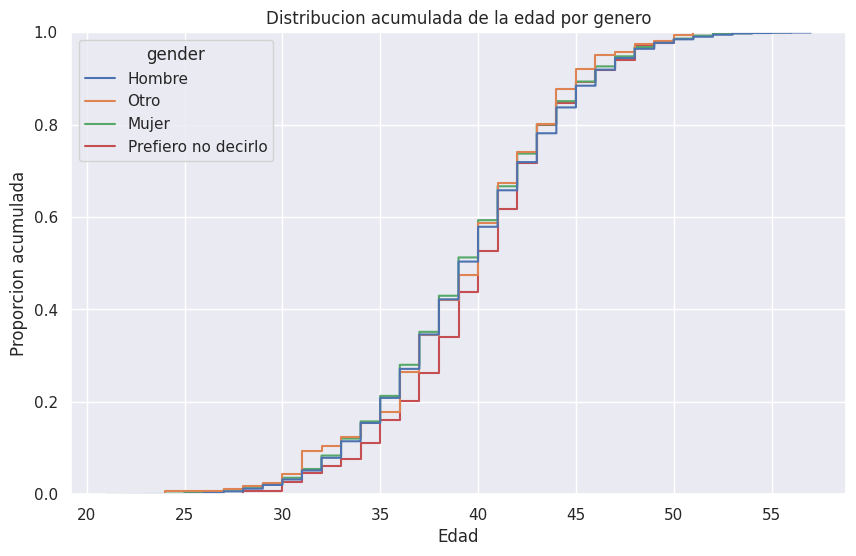

In [ ]:
print("ej 6)")
seaborn.set_theme(style="darkgrid")
plt.figure(figsize=(10,6))

# distribucion acumulada
seaborn.ecdfplot(data=new_df, x="age", hue="gender")

plt.title("Distribucion acumulada de la edad por genero")
plt.xlabel("Edad")
plt.ylabel("Proporcion acumulada")
# plt.legend(title="Genero")
plt.show()

# ej 7)
Grafique dos histogramas superpuestos, comparando las distribuciones de los salarios para seniors y para juniors. Utilice `clean_outliers` y grafique nuevamente. ¿Cuál es el valor por defecto? ¿Qué sucede cuando es muy bajo? ¿Y cuando es muy alto? ¿A qué distribuciones de las vistas en clase se parece más cada histograma? ¿Son distintas? ¿Qué las diferencia?


ej 7)

grafico 1, sin limpiar outliers


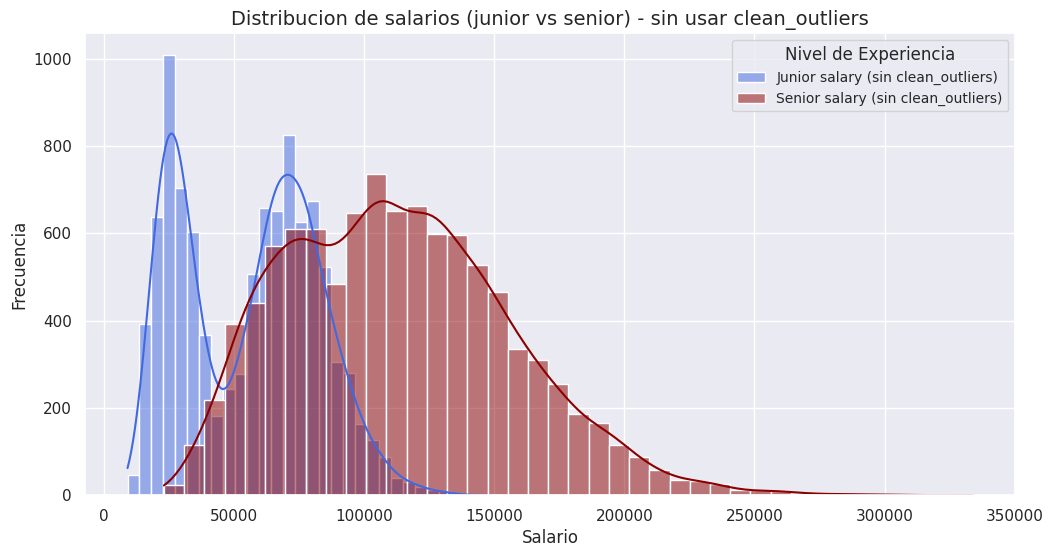

grafico 2, con limpieza de outliers


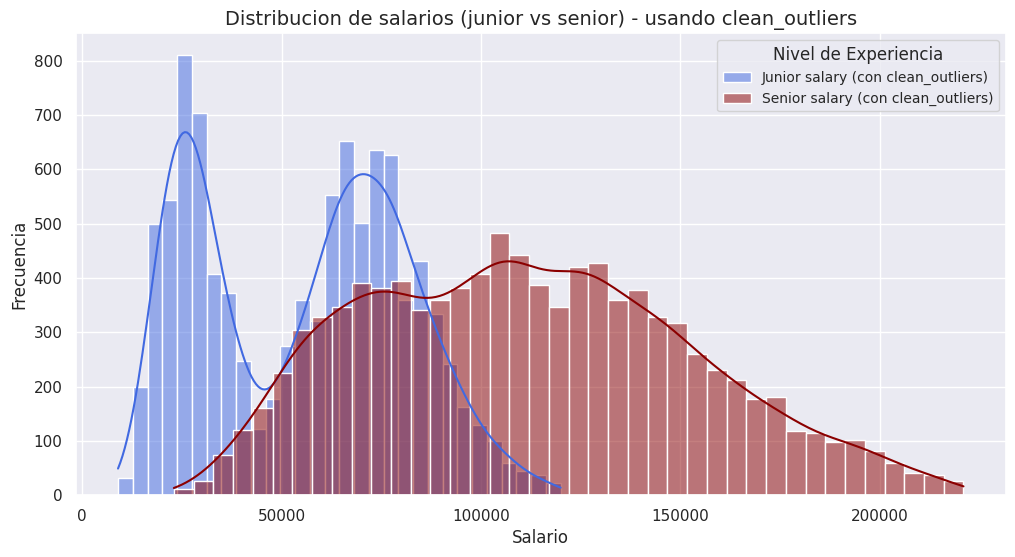

In [ ]:
# ! clean_outliers (histogramas, notebook)
def clean_outliers(dataset, column_name):
    """Devuelve el dataset sin los valores outlier de la columna @column_name.
    Criterio: mantener los valores dentro de ±2.5 desviaciones estándar."""
    interesting_col = dataset[column_name]
    mask_salarios_outlier = (
        numpy.abs(interesting_col - interesting_col.mean()) <= (2.5 * interesting_col.std()))
    return dataset[mask_salarios_outlier]

seaborn.set_theme(style="darkgrid")

print("ej 7)\n")
# royalblue es junior, darkred es senior

print("grafico 1, sin limpiar outliers")
# ! graf 1, sin limpiar outliers
plt.figure(figsize=(12,6))
seaborn.histplot(
    data=new_df,
    x="junior_programmer_salary",
    bins=30, kde=True,
    color="royalblue", alpha=0.5, label="Junior salary (sin clean_outliers)"
)
seaborn.histplot(
    data=new_df,
    x="senior_programmer_salary",
    bins=40, kde=True,
    color="darkred", alpha=0.5, label="Senior salary (sin clean_outliers)"
)
plt.title("Distribucion de salarios (junior vs senior) - sin usar clean_outliers", fontsize=14)
plt.xlabel("Salario", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.legend(title="Nivel de Experiencia", fontsize=10)
plt.show()

print("grafico 2, con limpieza de outliers")
# ! graf 2, usando clean_outliers
data_jr = clean_outliers(new_df, "junior_programmer_salary")["junior_programmer_salary"]
data_sr = clean_outliers(new_df, "senior_programmer_salary")["senior_programmer_salary"]

plt.figure(figsize=(12,6))
seaborn.histplot(
    data_jr,
    kde=True,
    bins=30,
    color="royalblue",
    alpha=0.5,
    label="Junior salary (con clean_outliers)"
)
seaborn.histplot(
    data_sr,
    kde=True,
    bins=40,
    color="darkred",
    alpha=0.5,
    label="Senior salary (con clean_outliers)"
)
plt.title("Distribucion de salarios (junior vs senior) - usando clean_outliers", fontsize=14)
plt.xlabel("Salario", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.legend(title="Nivel de Experiencia", fontsize=10)
plt.show()

### (I)¿Cuál es el valor por defecto?"

El valor por defecto de la funcion clean_outliers del notebook es de 2.5 que sería la desviacion estandar, que permite que los datos esten dentro de un rango +-2.5 de desviacion respecto a la medcia, para evitar valores extremos.

### (II)¿Que sucede cuando es muy bajo? ¿Y cuando es muy alto?

Lo que sucede, es que clean_outliers es una funcion de filtrado, para cuando es un valor bajo, este filtro es estricto y se eliminan valores validos, haciendose la distrbucion mas chica.
Cuando es un valor muy alto, el filtro no existe practicamente, entonces casi ningun dato se elimina y los valroes atipicos quedan dentro

### (III)¿A qué distribuciones de las vistas en clase se parece mas cada histograma? ¿Son distintas? ¿Qué las diferencia?

Las distribuciones se parecen a una distribucion log-normal, ya que concentran en un rango medio,  dispersando valores atipicos a los extremos.

De igual manera, su diferenciacion es el desplazamiento que tienen en el grafico, ej, los seniors están mas la derecha (tienen valores mayores) y tiene mas dispercion; en cambio los juniors esta mas a la izquierda, siendo mas concentrado por que el rango de salarios esta mas acotado. Siendo su diferenciacion principal, su nivel medio, su dispercion y amplitud de cola

# ej 8)
Usando los boxplots describa la distribución del ingreso senior en el rango de edad construido y agrupado por `gender`. ¿Son simétricas, sesgada a la izquierda o a la derecha?


ej 8)

Distribucion del ingreso senior por rango de edad y agrupado por gender
[(15, 20), (20, 25), (25, 30), (30, 35), (35, 40), (40, 45), (45, 50), (50, 57)]


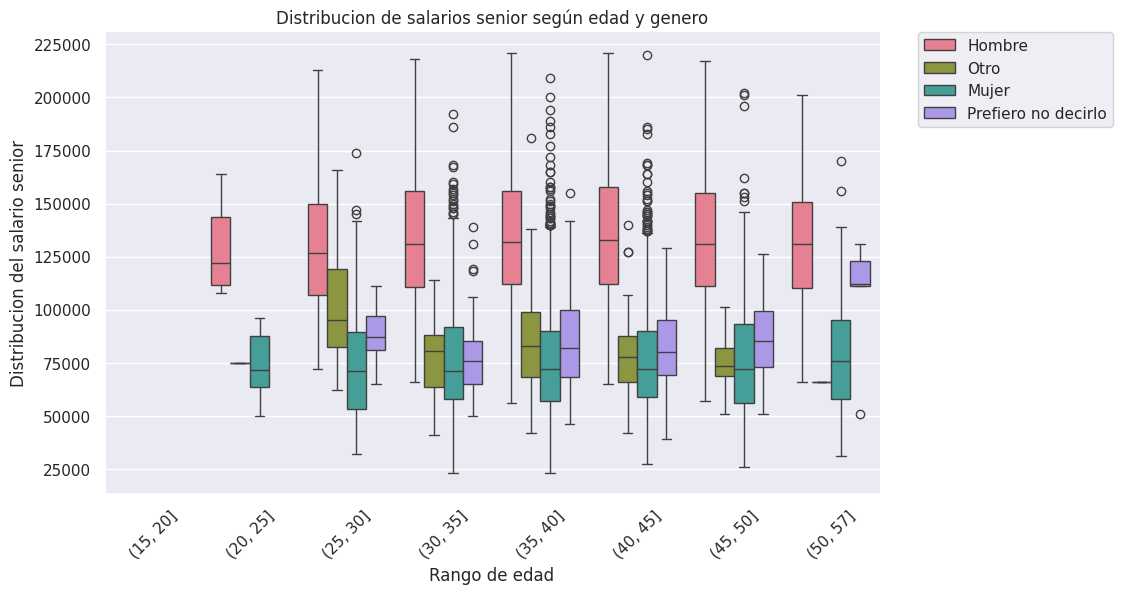

In [ ]:
# ! clean_outliers (histogramas, notebook)
def clean_outliers(dataset, column_name):
    """Devuelve el dataset sin los valores outlier de la columna @column_name.
    Criterio: mantener los valores dentro de ±2.5 desviaciones estándar."""
    interesting_col = dataset[column_name]
    mask_salarios_outlier = (
        numpy.abs(interesting_col - interesting_col.mean()) <= (2.5 * interesting_col.std()))
    return dataset[mask_salarios_outlier]

# ! to_categorical (heatmaps, notebook)
def to_categorical(column, bin_size=5, min_cut=15, max_cut=50):
    if min_cut is None:
        min_cut = int(round(column.min())) - 1
    value_max = int(numpy.ceil(column.max()))
    max_cut = min(max_cut, value_max)
    intervals = [(x, x + bin_size) for x in range(min_cut, max_cut, bin_size)]
    if max_cut != value_max:
        intervals.append((max_cut, value_max))
    print(intervals)
    return pandas.cut(column, pandas.IntervalIndex.from_tuples(intervals))

seaborn.set_theme(style="darkgrid")

print("ej 8)\n")
print("Distribucion del ingreso senior por rango de edad y agrupado por gender")

# cleanup
senior_programmer_data = clean_outliers(new_df, "senior_programmer_salary")
senior_programmer_data = senior_programmer_data[~senior_programmer_data.age.isnull()]

# categorias
senior_programmer_data['age'] = to_categorical(senior_programmer_data.age)

# grafico boxplot
plt.figure(figsize=(10,6))
seaborn.boxplot(data=senior_programmer_data,
                x='age', y='senior_programmer_salary',
                hue='gender', palette='husl')

plt.ylabel('Distribucion del salario senior')
plt.xlabel('Rango de edad')
plt.title('Distribucion de salarios senior según edad y genero')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
seaborn.despine()
plt.show()


Interpretacion a partir del grafico:

Los graficos de caja (boxplots), muestran la distribucion de una variable numerica, de una forma mas condensada que un histograma para este caso, rango de salario seniors, segun rangos de edad y agrupados de genero, cuando se demanda muchas distribuciones, siendo distintas entre ellas es util.
viendo el grafico, la distribucion es asimetrica positiva (sesgada a la derecha), ya que los valores estan concentras cerca de la mediana, y los vlaores mas altos, son mas largos, demostrando mas pago de salario
los hombres tienden a tener medianas un poco mas altas, pese a que la disperciones y la forma de la distribucion son parecidas


# ej 9)
Realice una comparación entre la edad y ambas estimaciones de sueldo **sin outliers**  usando pairplots.


ej 9)

Comparacion entre edad y ambas estimaciones de sueldo, sin outliers, pairplots


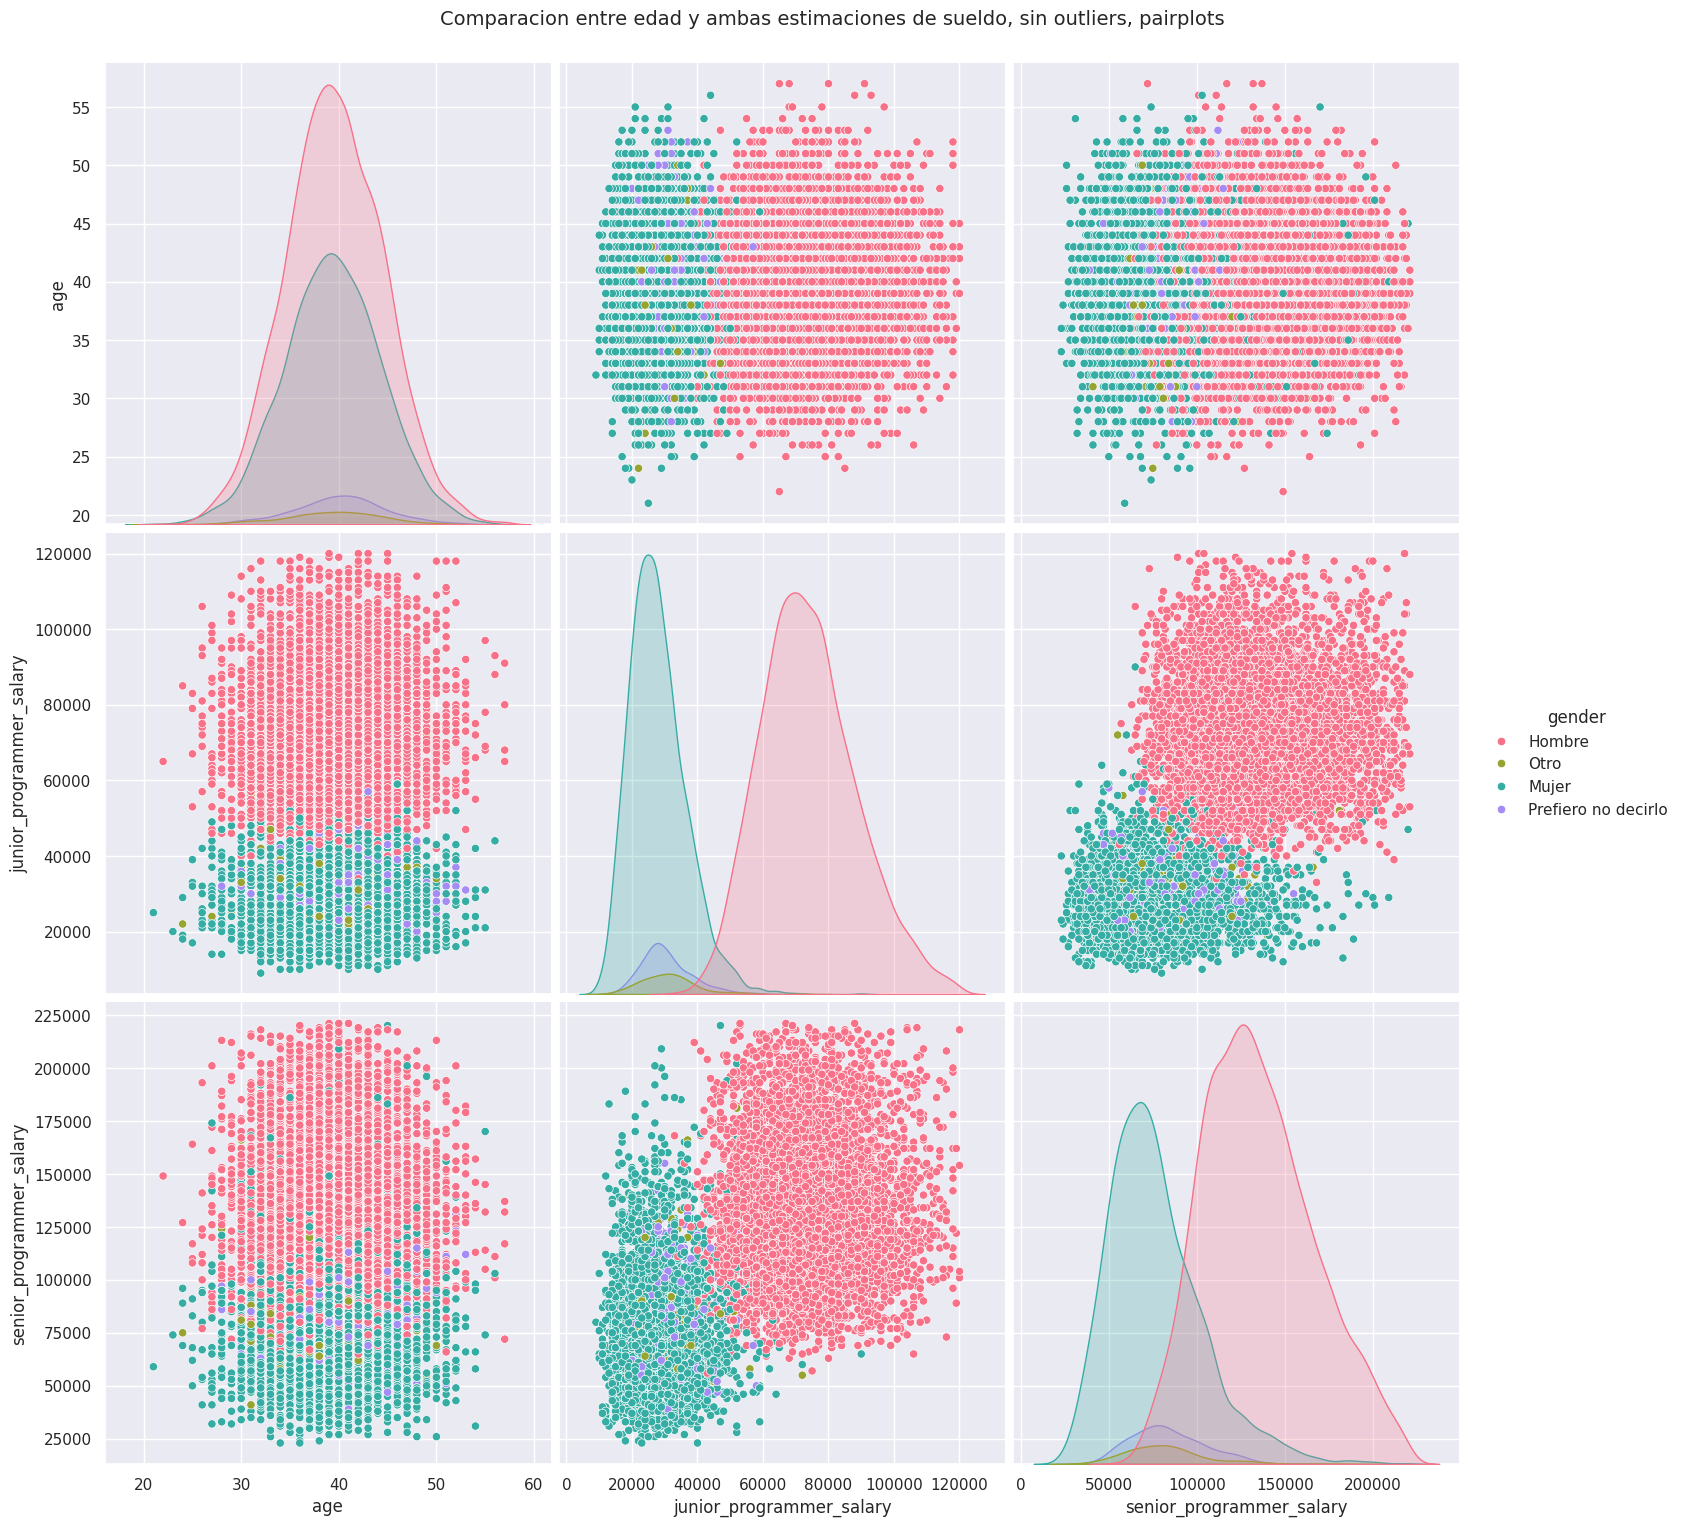

In [ ]:
# ! clean_outliers (histogramas, notebook)
def clean_outliers(dataset, column_name):
    """Devuelve el dataset sin los valores outlier de la columna @column_name.
    Criterio: mantener los valores dentro de ±2.5 desviaciones estándar."""
    interesting_col = dataset[column_name]
    mask_salarios_outlier = (
        numpy.abs(interesting_col - interesting_col.mean()) <= (2.5 * interesting_col.std()))
    return dataset[mask_salarios_outlier]

print("ej 9)\n")
print("Comparacion entre edad y ambas estimaciones de sueldo, sin outliers, pairplots")
# cleanup
pairplot_data = clean_outliers(new_df, "junior_programmer_salary")
pairplot_data = clean_outliers(pairplot_data, "senior_programmer_salary")
seaborn.set_theme(style="darkgrid")
# grafico pairplot sin outliers, dif por genero
seaborn.pairplot(
    data=pairplot_data,
    vars=["age", "junior_programmer_salary", "senior_programmer_salary"],
    hue="gender",
    height=5,
    palette="husl"
)
plt.suptitle("Comparacion entre edad y ambas estimaciones de sueldo, sin outliers, pairplots", y=1.02, fontsize=14)
plt.show()

# ej 10)
¿Qué puede decir de las distribuciones de salarios junior y senior?

Interpretacion a partir del grafico:

Los pairplots son muy utiles para comparar muchas variables numéricas al mismo tiempo
para este caso, se observa la relación entre la edad, y ambos salarios.
Las estimaciones de salario junior muestran una menos disprecion, mientras tanto que el salario senior tiene una mayor amplitud y valores mas altos
siendo ambas asimetricas positivas, sesgadas a la derecha